<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/C%C3%B3pia_de_MLP_MULTICAMADAS_2000_CLIENTES_COMPLETO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Para reprodutibilidade
np.random.seed(42)

# Quantidade de clientes
n_clientes = 2000  # > 1000 como você pediu

# 1. Gerar as features sintéticas
idades = np.random.randint(18, 75, size=n_clientes)  # idade entre 18 e 74
renda_mensal = np.random.normal(loc=4000, scale=1500, size=n_clientes)  # média 4000, desvio 1500
renda_mensal = np.clip(renda_mensal, 1000, 20000)  # limitar valores extremos

anos_como_cliente = np.random.randint(0, 15, size=n_clientes)  # 0 a 14 anos
score_satisfacao = np.random.randint(1, 11, size=n_clientes)   # 1 a 10
numero_compras_mes = np.random.poisson(lam=5, size=n_clientes) # média 5 compras/mês
usa_app = np.random.randint(0, 2, size=n_clientes)             # 0 ou 1
tem_cartao_loja = np.random.randint(0, 2, size=n_clientes)     # 0 ou 1

# Região categórica (Norte, Sul, Leste, Oeste)
regioes = np.random.choice(['Norte', 'Sul', 'Leste', 'Oeste'], size=n_clientes, p=[0.25, 0.25, 0.25, 0.25])

# 2. Gerar a variável alvo: gasto_anual (R$)
# Modelo "escondido" para gerar os dados:
# - renda e número de compras influenciam positivamente o gasto
# - anos como cliente e satisfação também
# - app e cartão somam um extra
# - região tem pequeno impacto aleatório

# Criar codificação simples para regiões para usar no cálculo base
regiao_factor = np.zeros(n_clientes)
regiao_factor[regioes == 'Norte'] = 0.9
regiao_factor[regioes == 'Sul'] = 1.1
regiao_factor[regioes == 'Leste'] = 1.0
regiao_factor[regioes == 'Oeste'] = 1.05

# Fórmula sintética
gasto_base = (
    renda_mensal * np.random.uniform(4, 8)  # gasto anual relacionado à renda
    + numero_compras_mes * np.random.uniform(100, 300) * 12
    + anos_como_cliente * np.random.uniform(50, 200)
    + score_satisfacao * np.random.uniform(20, 80)
    + usa_app * np.random.uniform(300, 1500)
    + tem_cartao_loja * np.random.uniform(500, 2000)
)

# Aplicar o fator de região
gasto_base = gasto_base * regiao_factor

# Adicionar ruído
ruido = np.random.normal(loc=0, scale=3000, size=n_clientes)
gasto_anual = gasto_base + ruido

# Garantir que não haja gasto negativo
gasto_anual = np.clip(gasto_anual, 500, None)

# 3. Montar o DataFrame
df_clientes = pd.DataFrame({
    'idade': idades,
    'renda_mensal': renda_mensal,
    'anos_como_cliente': anos_como_cliente,
    'score_satisfacao': score_satisfacao,
    'numero_compras_mes': numero_compras_mes,
    'usa_app': usa_app,
    'tem_cartao_loja': tem_cartao_loja,
    'regiao': regioes,
    'gasto_anual': gasto_anual
})

print("Primeiras linhas do dataset sintético de clientes:")
print(df_clientes.head())
print("\nDescrição estatística:")
print(df_clientes.describe(include='all'))

# 4. Salvar como CSV (simulando um dataset do Kaggle)
nome_arquivo = "clientes_sintetico.csv"
df_clientes.to_csv(nome_arquivo, index=False)
print(f"\nDataset salvo em: {nome_arquivo}")

from google.colab import files
files.download("clientes_sintetico.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Primeiras linhas do dataset sintético de clientes:
   idade  renda_mensal  anos_como_cliente  score_satisfacao  \
0     56   7790.398639                  6                 2   
1     69   3203.696841                  4                 4   
2     46   3265.840836                  0                 5   
3     32   5566.241316                 11                 7   
4     60   5022.837234                  8                 2   

   numero_compras_mes  usa_app  tem_cartao_loja regiao   gasto_anual  
0                   5        0                1  Norte  61388.311326  
1                  13        0                1  Norte  43436.856580  
2                   4        0                0  Norte  26740.772578  
3                   3        1                1  Oeste  53897.811545  
4                   9        1                1  Oeste  55878.270014  

Descrição esta

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Primeiras linhas do dataset sintético de clientes:
   idade  renda_mensal  anos_como_cliente  score_satisfacao  \
0     56   7790.398639                  6                 2   
1     69   3203.696841                  4                 4   
2     46   3265.840836                  0                 5   
3     32   5566.241316                 11                 7   
4     60   5022.837234                  8                 2   

   numero_compras_mes  usa_app  tem_cartao_loja regiao   gasto_anual  
0                   5        0                1  Leste  43185.304586  
1                  13        0                1  Norte  33299.028339  
2                   4        0                0    Sul  17925.680252  
3                   3        1                1    Sul  34822.844002  
4                   9        1                1  Leste  34100.893839  

Descrição estatística:
              idade  renda_mensal  anos_como_cliente  score_satisfacao  \
count   2000.000000   2000.000000        2000.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Primeiras linhas do dataset de clientes:
   idade  renda_mensal  anos_como_cliente  score_satisfacao  \
0     56   7790.398639                  6                 2   
1     69   3203.696841                  4                 4   
2     46   3265.840836                  0                 5   
3     32   5566.241316                 11                 7   
4     60   5022.837234                  8                 2   

   numero_compras_mes  usa_app  tem_cartao_loja regiao   gasto_anual  
0                   5        0                1  Norte  61388.311326  
1                  13        0                1  Norte  43436.856580  
2                   4        0                0  Norte  26740.772578  
3                   3        1                1  Oeste  53897.811545  
4                   9        1                1  Oeste  55878.270014  

Info:
<class 'pandas.cor

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


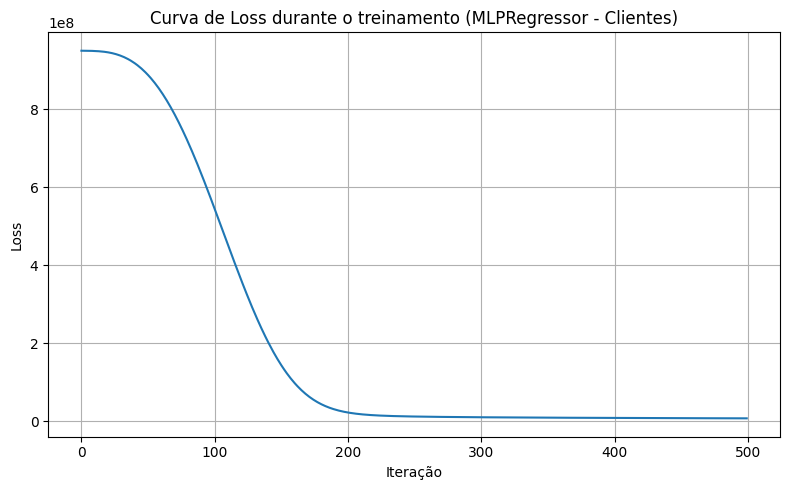

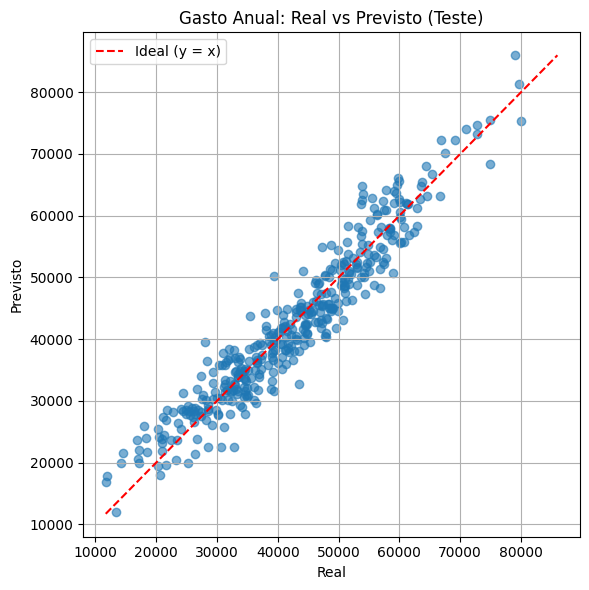

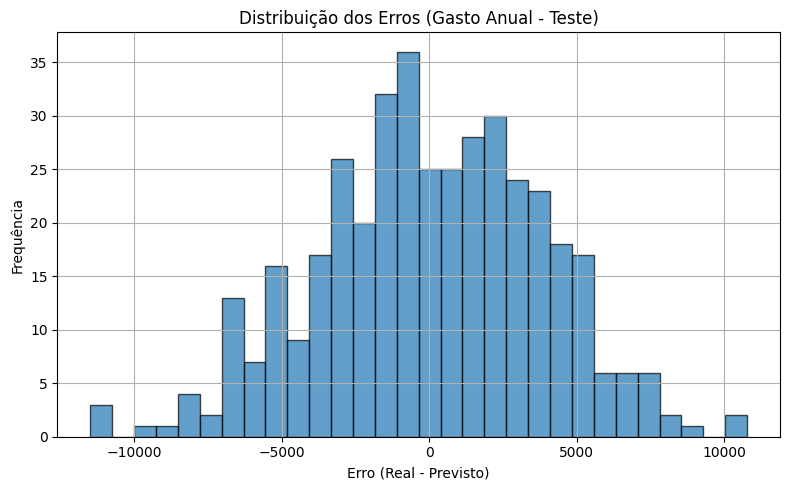

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==============================
# 1. CARREGAR O DATASET DE CLIENTES
# ==============================

arquivo_csv = "clientes_sintetico.csv"
df = pd.read_csv('/content/clientes_sintetico.csv')

print("Primeiras linhas do dataset de clientes:")
print(df.head())
print("\nInfo:")
print(df.info())

# ==============================
# 2. PRÉ-PROCESSAMENTO
# ==============================

# Transformar variável categórica 'regiao' em dummies (one-hot encoding)
df = pd.get_dummies(df, columns=['regiao'], drop_first=True)
# Agora, teremos colunas como: regiao_Leste, regiao_Norte, regiao_Oeste (Sul é referência, por exemplo)

# Definir target
nome_coluna_target = "gasto_anual"

X = df.drop(columns=[nome_coluna_target])
y = df[nome_coluna_target]

# Conferir NaNs (em princípio não deve haver)
print("\nValores ausentes por coluna:")
print(df.isna().sum())

# ==============================
# 3. TREINO / TESTE
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"\nTamanho treino: {X_train.shape}, teste: {X_test.shape}")

# ==============================
# 4. NORMALIZAÇÃO
# ==============================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 5. DEFINIÇÃO DA REDE MLP
# ==============================

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    random_state=42,
    max_iter=500,
    learning_rate_init=0.001,
    verbose=True
)

# ==============================
# 6. TREINAMENTO
# ==============================

print("\nTreinando MLPRegressor para prever gasto_anual...")
mlp.fit(X_train_scaled, y_train)

print("\nTreinamento concluído.")
print(f"Iterações usadas: {mlp.n_iter_}")

# ==============================
# 7. PREVISÃO
# ==============================

y_train_pred = mlp.predict(X_train_scaled)
y_test_pred = mlp.predict(X_test_scaled)

# ==============================
# 8. MÉTRICAS (MAE, MSE, RMSE, R²)
# ==============================

mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("\n===== MÉTRICAS - TREINO =====")
print(f"MAE  (train): {mae_train:.2f}")
print(f"MSE  (train): {mse_train:.2f}")
print(f"RMSE (train): {rmse_train:.2f}")
print(f"R²   (train): {r2_train:.4f}")

print("\n===== MÉTRICAS - TESTE =====")
print(f"MAE  (test): {mae_test:.2f}")
print(f"MSE  (test): {mse_test:.2f}")
print(f"RMSE (test): {rmse_test:.2f}")
print(f"R²   (test): {r2_test:.4f}")

# ==============================
# 9. PLOTAGENS
# ==============================

# 9.1. Curva de Loss
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_)
plt.title("Curva de Loss durante o treinamento (MLPRegressor - Clientes)")
plt.xlabel("Iteração")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# 9.2. Reais vs Previstos (Teste)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Ideal (y = x)")
plt.title("Gasto Anual: Real vs Previsto (Teste)")
plt.xlabel("Real")
plt.ylabel("Previsto")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 9.3. Distribuição dos erros (Teste)
erros = y_test - y_test_pred
plt.figure(figsize=(8, 5))
plt.hist(erros, bins=30, edgecolor='k', alpha=0.7)
plt.title("Distribuição dos Erros (Gasto Anual - Teste)")
plt.xlabel("Erro (Real - Previsto)")
plt.ylabel("Frequência")
plt.grid(True)
plt.tight_layout()
plt.show()